# Week 2 Day 1 — SHAP Explainability for ICU Sepsis Prediction

## ICU Early Warning Prediction System

In Week 1, several machine learning models were trained and compared for ICU sepsis prediction.

The best balanced model was:

**Gradient Boosting + SMOTE**

Week 2 focuses on making the model more explainable and closer to clinical deployment.

The objective of this notebook is to use SHAP explainability to understand how each physiological feature contributes to sepsis risk prediction.

SHAP helps answer an important clinical AI question:


> Which patient features increased or decreased the predicted sepsis risk?

In [1]:
# Install SHAP if it is not already installed
!pip install shap

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/3 [slicer]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ------------- 2/3 [shap]
   -------------------------- ---------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\User\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 1. Import Required Libraries

This section imports the required libraries for:

- data loading
- model training
- imbalance handling using SMOTE
- SHAP explainability
- visualization
- saving outputs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Configure Project Paths

The project folders are configured to keep Week 2 outputs organized.

Figures from this notebook will be saved inside:

`figures/day8_shap_explainability`

Results will be saved inside:

`results/`

In [14]:
from pathlib import Path

# Current project root
PROJECT_ROOT = Path.cwd().parent

# Paths
DATA_PATH = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures" / "day8"
# Create folders if they do not exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Results path:", RESULTS_DIR)
print("Figures path:", FIGURES_DIR)

# Check if figure folder exists
print("Figure directory exists:", FIGURES_DIR.exists())

Project root: c:\Users\User\OneDrive\Desktop\icu-early-warning-system
Data path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\data\processed
Results path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\results
Figures path: c:\Users\User\OneDrive\Desktop\icu-early-warning-system\figures\day8
Figure directory exists: True


## 3. Load Processed ICU Patient-Level Dataset

The processed dataset created in Week 1 Day 2 is loaded.

Each row represents one ICU patient, and each column represents engineered clinical features such as:

- heart rate
- oxygen saturation
- blood pressure
- temperature
- respiratory rate
- ICU length of stay
- sepsis label

In [4]:
data_file = DATA_PATH / "day2_patient_level_features.csv"

df = pd.read_csv(data_file)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (100, 18)


,Patient_ID,HR_mean,HR_max,HR_min,O2Sat_mean,O2Sat_min,Temp_mean,Temp_max,SBP_mean,SBP_min,MAP_mean,MAP_min,Resp_mean,Resp_max,Age_first,Gender_first,ICULOS_max,SepsisLabel_max
0,p000001,101.907407,117.0,76.0,91.453704,85.0,36.735185,37.44,127.870370,78.0,88.321111,44.00,24.555556,32.0,83.14,0,54,0
1,p000002,62.173913,94.0,54.0,97.043478,94.0,36.206087,37.00,129.043478,114.0,67.239130,50.50,14.630435,27.0,75.91,0,23,0
2,p000003,79.968750,93.0,68.0,95.375000,91.0,37.465000,38.61,139.760417,121.0,81.149167,62.67,25.302083,40.0,45.82,0,48,0
3,p000004,102.172414,113.0,89.0,98.189655,95.5,36.463103,37.00,113.017241,90.0,67.063103,34.00,18.758621,26.0,65.71,0,29,0
4,p000005,76.604167,88.0,61.0,97.677083,96.0,37.072292,37.33,135.072917,114.0,90.364583,73.00,15.447917,21.0,28.09,1,49,0


In [5]:
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['Patient_ID', 'HR_mean', 'HR_max', 'HR_min', 'O2Sat_mean', 'O2Sat_min', 'Temp_mean', 'Temp_max', 'SBP_mean', 'SBP_min', 'MAP_mean', 'MAP_min', 'Resp_mean', 'Resp_max', 'Age_first', 'Gender_first', 'ICULOS_max', 'SepsisLabel_max']


## 4. Define Features and Target

The target variable is:

`SepsisLabel_max`

This indicates whether the patient developed sepsis during the ICU stay.

The feature matrix excludes:

- `Patient_ID`
- `SepsisLabel_max`

In [6]:
target_col = "SepsisLabel_max"

X = df.drop(columns=["Patient_ID", target_col])
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Feature matrix shape: (100, 16)
Target shape: (100,)


,HR_mean,HR_max,HR_min,O2Sat_mean,O2Sat_min,Temp_mean,Temp_max,SBP_mean,SBP_min,MAP_mean,MAP_min,Resp_mean,Resp_max,Age_first,Gender_first,ICULOS_max
0,101.907407,117.0,76.0,91.453704,85.0,36.735185,37.44,127.870370,78.0,88.321111,44.00,24.555556,32.0,83.14,0,54
1,62.173913,94.0,54.0,97.043478,94.0,36.206087,37.00,129.043478,114.0,67.239130,50.50,14.630435,27.0,75.91,0,23
2,79.968750,93.0,68.0,95.375000,91.0,37.465000,38.61,139.760417,121.0,81.149167,62.67,25.302083,40.0,45.82,0,48
3,102.172414,113.0,89.0,98.189655,95.5,36.463103,37.00,113.017241,90.0,67.063103,34.00,18.758621,26.0,65.71,0,29
4,76.604167,88.0,61.0,97.677083,96.0,37.072292,37.33,135.072917,114.0,90.364583,73.00,15.447917,21.0,28.09,1,49


## 5. Train-Test Split

A stratified train-test split is used to preserve the same sepsis/non-sepsis ratio in both training and testing sets.

This is important because the dataset is imbalanced.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training shape: (75, 16)
Testing shape: (25, 16)

Training class distribution:
SepsisLabel_max
0    64
1    11
Name: count, dtype: int64

Testing class distribution:
SepsisLabel_max
0    22
1     3
Name: count, dtype: int64


## 6. Apply SMOTE to Training Data Only

SMOTE is applied only to the training set.

This prevents data leakage because synthetic samples must not be created using information from the test set.

In [8]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training shape:", X_train.shape)
print("SMOTE training shape:", X_train_smote.shape)

print("\nOriginal class distribution:")
print(y_train.value_counts())

print("\nSMOTE class distribution:")
print(y_train_smote.value_counts())

Original training shape: (75, 16)
SMOTE training shape: (128, 16)

Original class distribution:
SepsisLabel_max
0    64
1    11
Name: count, dtype: int64

SMOTE class distribution:
SepsisLabel_max
1    64
0    64
Name: count, dtype: int64


## 7. Train Gradient Boosting + SMOTE Model

The selected Week 1 model is retrained here so that SHAP explanations can be generated.

The model used is:

**Gradient Boosting Classifier trained on SMOTE-balanced data**

In [9]:
gb_smote_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_smote_model.fit(X_train_smote, y_train_smote)

print("Gradient Boosting + SMOTE model trained successfully.")

Gradient Boosting + SMOTE model trained successfully.


## 8. Evaluate Model Before Explainability

Before interpreting the model, we confirm that it is producing valid predictions.

This step connects Week 2 explainability to the Week 1 model evaluation workflow.

In [10]:
y_pred = gb_smote_model.predict(X_test)
y_prob = gb_smote_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", round(roc_auc, 3))

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88        22
           1       0.33      0.67      0.44         3

    accuracy                           0.80        25
   macro avg       0.64      0.74      0.66        25
weighted avg       0.87      0.80      0.83        25

ROC-AUC: 0.758


## 9. Create SHAP Explainer

SHAP values explain how each feature contributes to the model prediction.

For tree-based models, SHAP can calculate feature contributions efficiently.

Positive SHAP values increase predicted sepsis risk.

Negative SHAP values decrease predicted sepsis risk.

In [11]:
explainer = shap.Explainer(gb_smote_model, X_train_smote)

shap_values = explainer(X_test)

print("SHAP values calculated successfully.")
print("SHAP values shape:", shap_values.values.shape)

Background dataset has 128 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=128 when initializing the masker.


SHAP values calculated successfully.
SHAP values shape: (25, 16)


## 10. SHAP Summary Plot

The SHAP summary plot shows the most influential features across all test patients.

This helps identify which physiological variables most strongly influenced sepsis prediction.

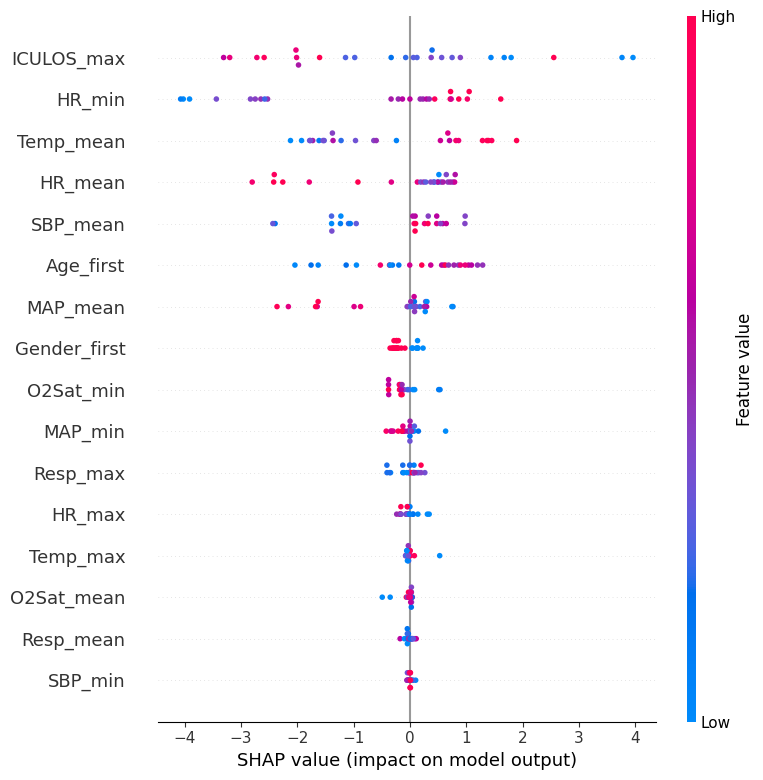

In [15]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. SHAP Bar Plot

The SHAP bar plot ranks features by their average absolute impact on model predictions.

This is useful for identifying the most important clinical predictors overall.

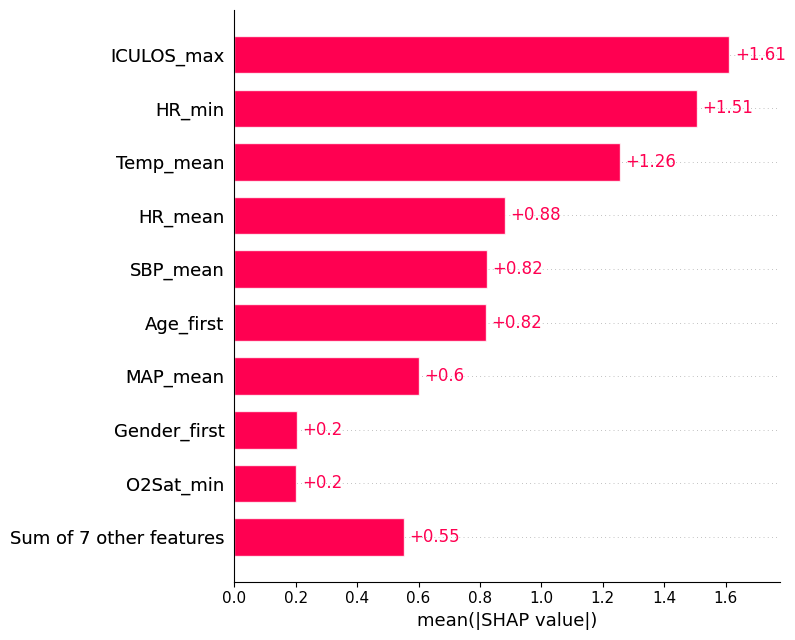

In [16]:
plt.figure()

shap.plots.bar(
    shap_values,
    show=False
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_bar_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Explain One Patient Prediction

This section explains one individual patient prediction.

This is important for clinical AI because doctors need to understand why a specific patient was classified as high-risk or low-risk.

In [17]:
patient_index = 0

patient_data = X_test.iloc[[patient_index]]
patient_probability = gb_smote_model.predict_proba(patient_data)[0, 1]
patient_prediction = gb_smote_model.predict(patient_data)[0]

print("Selected patient index:", patient_index)
print("Predicted sepsis probability:", round(patient_probability, 3))
print("Predicted class:", patient_prediction)

if patient_prediction == 1:
    print("Clinical interpretation: High sepsis risk")
else:
    print("Clinical interpretation: Low sepsis risk")

Selected patient index: 0
Predicted sepsis probability: 0.0
Predicted class: 0
Clinical interpretation: Low sepsis risk


## 13. SHAP Waterfall Plot for One Patient

The SHAP waterfall plot explains how each feature pushed the prediction toward higher or lower sepsis risk.

This provides patient-level interpretability.

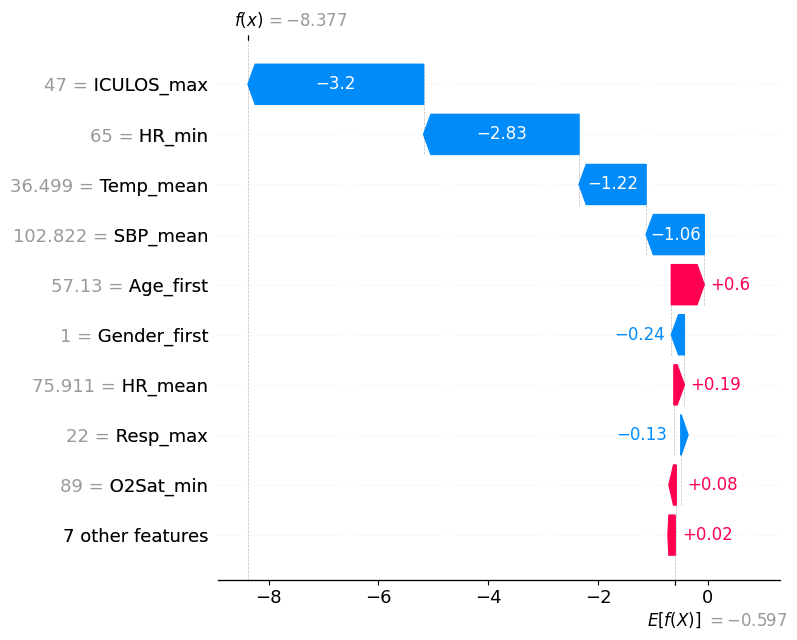

In [18]:
shap.plots.waterfall(
    shap_values[patient_index],
    show=False
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "patient_level_shap_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Save SHAP Feature Importance Results

The mean absolute SHAP value is calculated for each feature.

This creates a clean table of explainable feature importance.

In [19]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP_Value": np.abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP_Value",
    ascending=False
)

shap_importance.to_csv(
    RESULTS_DIR / "day8_shap_feature_importance.csv",
    index=False
)

shap_importance

,Feature,Mean_Absolute_SHAP_Value
15,ICULOS_max,1.611580
2,HR_min,1.505531
5,Temp_mean,1.255464
0,HR_mean,0.881130
7,SBP_mean,0.821450
13,Age_first,0.818141
9,MAP_mean,0.600732
14,Gender_first,0.203833
4,O2Sat_min,0.202492
10,MAP_min,0.137095


## 15. Clinical Interpretation of SHAP Results

SHAP explainability shows which patient-level physiological features contributed most to sepsis risk prediction.

Features with higher SHAP importance have a stronger effect on the model output.

Clinically, this is important because the model is not only predicting risk, but also showing which vital signs or patient characteristics influenced the decision.

This improves trust, transparency, and clinical interpretability.

At this stage, the ICU Early Warning Prediction System is moving from pure model performance toward explainable medical AI.

In [20]:
print("Week 2 Day 1 completed successfully.")
print("Generated outputs:")
print("- SHAP summary plot")
print("- SHAP bar plot")
print("- Patient-level SHAP waterfall plot")
print("- SHAP feature importance CSV")

Week 2 Day 1 completed successfully.
Generated outputs:
- SHAP summary plot
- SHAP bar plot
- Patient-level SHAP waterfall plot
- SHAP feature importance CSV
